# Practical 2 report: from relationships to predictive models

**Student:** Tetiana

**Date:** 16-09-26

**Practical:** 2 - Regression and evaluation


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split



In [19]:
diabetes = load_diabetes(as_frame=True)
diabetes_df = diabetes.frame.copy()
diabetes_df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


## 2. Data-preparation readiness

Complete the checklist before describing modelling results. Tick an item only after checking the data or documenting a justified decision.

### Scientific purpose and provenance

- [x] Is the biological question and prediction task stated clearly?
- [x] Is the unit of observation clear?
- [x] Do I know where the data came from, how they were generated, and under which access conditions they may be used?
- [x] Have I recorded the data version, processing history, and transformations already applied?

* 1 row = 1 patient's indicators
* data is already standartizesed
* everything is clear

### Table shape and identifiers

- [x] Is the table tidy: one observation per row, one variable per column, and one value per cell?
- [x] If needed, have I transposed the original assay into the format expected by the analysis tool?
- [x] Are row names, column names, and identifiers clear, unique, and stable?
- [x] Can every feature and observation be traced to its source?
- [x] Are the feature matrix and metadata aligned by an explicit identifier rather than row order?

### Types, values, and measurement meaning

- [x] Are numerical, categorical, ordinal, text, date, and identifier columns correctly classified?
- [x] Are units, scales, encodings, reference categories, and detection limits understood?
- [x] Have impossible values, inconsistent labels, unexpected categories, constant features, and extreme values been checked?
- [x] Are normalization, scaling, log transformation, and batch-correction steps documented?

In [6]:
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [15]:
diabetes_df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


### Missing values

- [ ] Have missing values been detected using all representations, not only `NaN`?
- [ ] Have missing values been measured by row, column, and relevant group?
- [ ] Do I know whether missingness is structural, technical, or plausibly related to biology or the target?
- [ ] Have retention, removal, or imputation been justified?
- [ ] If imputing, will the imputer be fitted on training data only?

In [17]:
diabetes_df.isna().sum()

,0
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0


### Replicates, dependence, and grouping

- [x] Have exact and near-duplicate observations been checked?
- [x] Are observations biological replicates, technical replicates, repeated measurements, pseudo-replicates, or independent samples?
- [x] Is the independent biological unit identified by a grouping variable?
- [x] Will related observations remain in the same train/validation/test split?
- [x] Is the provenance of synthetic or augmented observations recorded?

### Target, leakage, confounding, and reproducibility

- [x] Is the target defined before modelling?
- [x] Have identifiers, post-outcome variables, duplicated target information, and other leakage sources been excluded?
- [x] Have batch, site, subject, treatment, sex, age, time, and other possible confounders been considered?
- [x] Does the planned split represent the biological generalization question?
- [x] Are random seeds, software versions, file names, shapes, and preprocessing decisions recorded?

**Preparation summary:**

- Biological unit: [One patient]
- Number of observations and features: [442 observations, 10 predictor features + 1 target]
- Target and feature definition: [Target is the quantitative measure of diabetes disease progression one year after baseline. Features are baseline physiological measurements (age, sex, bmi, bp, and 6 blood serum measurements).]
- Missing-value decision: [No missing values, no imputation needed]
- Replicate/grouping decision: [Independent patients. No biological replicates or grouping variables are indicated]
- Main confounder or leakage source: [Age and sex could act as confounders for biological measurements. No obvious leakage variables.]
- Train/test split and justification: [A standard random split (e.g., 80/20) is appropriate because observations represent independent patients.]
- Remaining concerns: [Predictors are already transformed and standardized, therefore we can't make direct clinical interpretation of coefficients.]

## 3 Your  task: Diabetes regression

### 3.1 Data presentation



Identify:

- one observation;
  * A single patient's baseline physiological measurements and subsequent disease progression
- the target variable;
  * The target column, which is a quantitative measure of disease progression one year after the baseline measurements.
- predictor variables;
  * age, sex, bmi, bp, and six blood serum measurements (s1, s2,s3, s4, s5, s6).
- dimensionality of the dataset;
  * 442 rows (observations) and 11 columns (10 predictors + 1 target).
- whether the predictors and target have physical units or transformed scales.
  * the predictors are standardized (transformed scales)
  * the target variable retains its physical units

### 3.2 Descriptive analysis

- Summarize the target.
- Visualize its distribution.
- Visualize at least three predictor-target relationships.
- State the biological or predictive question addressed by each plot.

In [21]:
diabetes_df["target"].describe()

,target
count,442.000000
mean,152.133484
std,77.093005
min,25.000000
25%,87.000000
50%,140.500000
75%,211.500000
max,346.000000


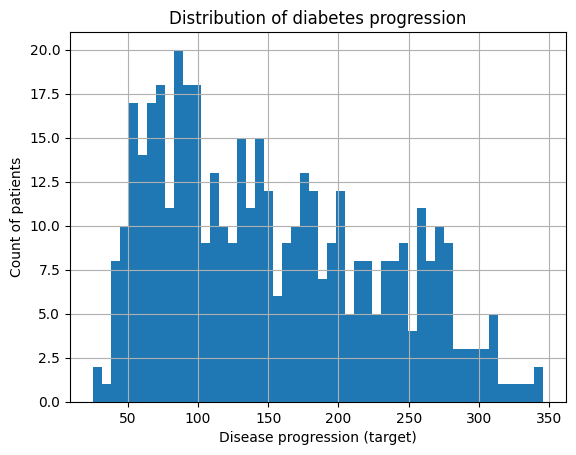

In [25]:
diabetes_df["target"].hist(bins=50)
plt.xlabel("Disease progression (target)")
plt.ylabel("Count of patients")
plt.title("Distribution of diabetes progression")
plt.show()

the distribution of diabetes progression is slightly right-skewed

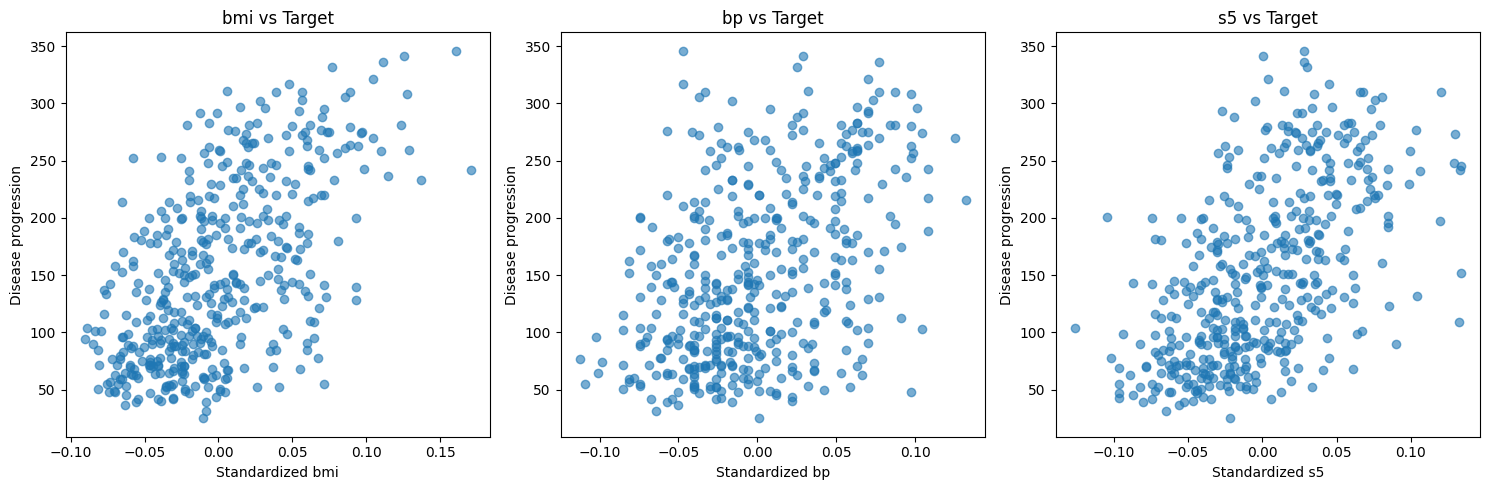

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
features_to_plot = ["bmi", "bp", "s5"]

for ax, feature in zip(axes, features_to_plot):
    ax.scatter(diabetes_df[feature], diabetes_df["target"], alpha=0.6)
    ax.set_xlabel(f"Standardized {feature}")
    ax.set_ylabel("Disease progression")
    ax.set_title(f"{feature} vs Target")

plt.tight_layout()
plt.show()

There are positive linear associations between the target and all three standardized predictors.

Biological/Predictive Questions Addressed:

* BMI plot: Does a higher baseline Body Mass Index predict a more severe progression of diabetes?

* BP plot: Is elevated baseline blood pressure associated with increased disease progression?

* s5 plot: Can higher levels of the s5 blood serum marker reliably predict greater diabetes progression?

### 3.3 Correlation

- Calculate correlation using ar least 2 different methods.
- Identify the predictor most strongly correlated with the target.
- Compare results.
- Explain why correlation is not sufficient for feature selection or causal interpretation.

In [30]:
# Pearson
pearson_corr = diabetes_df.corr(method="pearson")
pearson_corr["target"].sort_values(ascending=False)

,target
target,1.000000
bmi,0.586450
s5,0.565883
bp,0.441482
s4,0.430453
s6,0.382483
s1,0.212022
age,0.187889
s2,0.174054
sex,0.043062


In [31]:
# Spearman
spearman_corr = diabetes_df.corr(method="spearman")
spearman_corr["target"].sort_values(ascending=False)

,target
target,1.000000
s5,0.589416
bmi,0.561382
s4,0.448931
bp,0.416241
s6,0.350792
s1,0.232429
age,0.197822
s2,0.195834
sex,0.037401


* Calculated Methods: Pearson (linear association) and Spearman (monotonic association based on ranks)
* Strongest Predictor:
  * Pearson: bmi (0.586)
  * Spearman: s5 (0.589)
* Comparison:
  * both methods highlight bmi and s5 as the most influential predictors, and the similarity in their scores indicates that these relationships are mostly linear.
* Explain why correlation is not sufficient for feature selection or causal interpretation.
  * сorrelation shows association, not causation. It is insufficient for feature selection because it ignores potential multicollinearity, interaction effect and hidden biological factors.

### 4.4 Simple regression

Choose one predictor and fit a simple linear regression. Report and interpret:

- intercept;
- slope;
- the scale of the predictor;
- whether the slope is a causal effect.

In [32]:
X_simple = diabetes_df[["bmi"]]
y = diabetes_df["target"]

In [33]:
simple_model = LinearRegression()
simple_model.fit(X_simple, y)

LinearRegression()

In [34]:
print("Intercept:", simple_model.intercept_)
print("Slope:", simple_model.coef_[0])

Intercept: 152.13348416289617
Slope: 949.4352603840387


- intercept: 152.13. Predicted baseline disease progression for a patient with an average BMI (because the predictor is mean-centered).
- slope: 949.44. If standardized BMI increase in 1 unit, disease progression will increase in 949.44 unit
- the scale of the predictor: stantartized (not original physical units)
- whether the slope is a causal effect: no, the slope represents a predictive association, not a causal effect, as it does not account for other biological factors.

### 4.5 Residual diagnostics

Produce:

- observed versus predicted plot;
- residuals versus fitted plot;
- residual histogram;
- Q-Q plot.

Discuss linearity, homoscedasticity, residual normality, unusual observations, and any limitations of the diagnostics.

In [36]:
y_pred_simple=simple_model.predict(X_simple)
residuals = y-y_pred_simple

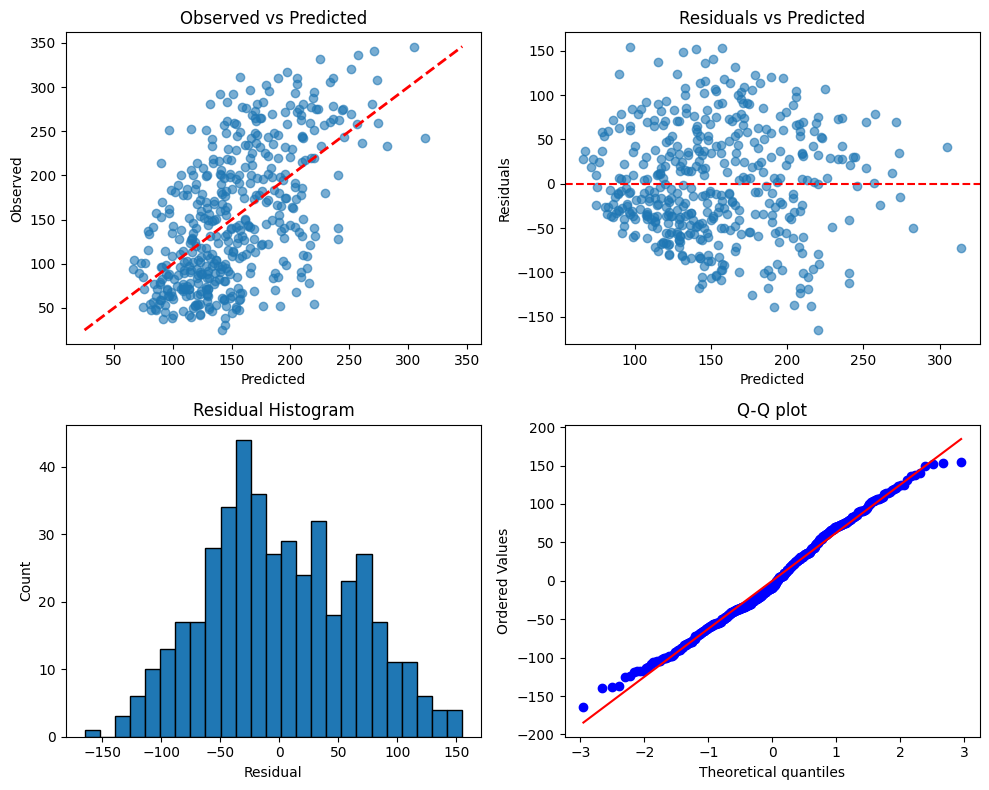

In [39]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0, 0].scatter(y_pred_simple, y, alpha=0.6)
axs[0, 0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axs[0, 0].set_xlabel("Predicted")
axs[0, 0].set_ylabel("Observed")
axs[0, 0].set_title("Observed vs Predicted")

axs[0, 1].scatter(y_pred_simple, residuals, alpha=0.6)
axs[0, 1].axhline(0, color='r', linestyle='--')
axs[0, 1].set_xlabel("Predicted")
axs[0, 1].set_ylabel("Residuals")
axs[0, 1].set_title("Residuals vs Predicted")

axs[1, 0].hist(residuals, bins=25, edgecolor='k')
axs[1, 0].set_xlabel("Residual")
axs[1, 0].set_ylabel("Count")
axs[1, 0].set_title("Residual Histogram")

stats.probplot(residuals, dist="norm", plot=axs[1, 1])
axs[1, 1].set_title("Q-Q plot")

plt.tight_layout()
plt.show()

* Linearity: mostly met. Residuals are randomly scattered around zero with no curved patterns.

* Homoscedasticity: slightly violated. The spread of residuals widens for higher predicted values.  

* Residual Normality: mostly normal (bell-shaped), but the Q-Q plot tails deviate, showing issues with extreme values.   

* Unusual observations: a few prominent outliers exist (eg, residuals below -150).   

* Limitations: visual checks are subjective, and the wide variance shows that a single predictor is insufficient

### 4.6 Multiple regression and multicollinearity

Fit a model using all available predictors. Inspect:

- coefficients;
- predictor correlations;
- possible multicollinearity;
- whether standardized predictors change coefficient interpretation.

In [42]:
X_multi = diabetes_df.drop(columns="target")

In [43]:
multi_model = LinearRegression()
multi_model.fit(X_multi, y)

LinearRegression()

In [49]:
coef_df = pd.DataFrame({"Feature": X_multi.columns, "Coefficient": multi_model.coef_})
coef_df

,Feature,Coefficient
0,age,-10.009866
1,sex,-239.815644
2,bmi,519.845920
3,bp,324.384646
4,s1,-792.175639
5,s2,476.739021
6,s3,101.043268
7,s4,177.063238
8,s5,751.273700
9,s6,67.626692


In [50]:
# multicollinearity
X_multi.corr()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
age,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731
sex,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133
bmi,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680
bp,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430
s1,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717
s2,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600
s3,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697
s4,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212
s5,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669
s6,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000


* Coefficients: s5 (+751.3) and bmi (+519.8) have the strongest positive effects. s1 (-792.2) is the strongest negative.

* Multicollinearity: рigh among blood features, notably between s1 and s2 (r = 0.897).

* Interpretation instability: highly correlated predictors like s1 and s2 received large opposite signs, indicating the model is unstable and using them to cancel each other out.

* Standardization: since predictors are scaled, coefficient sizes directly show each feature's relative importance.

### 4.7 Train/test evaluation

Create a justified train/test split and report MAE, MSE, RMSE, and $R^2$. Compare simple and multiple regression on test data.

Explain whether the split answers the intended biological or clinical generalization question.

In [46]:
def eval_model(model, X, y_true, name):
    pred = model.predict(X)
    return {
        "Model": name,
        "MAE": mean_absolute_error(y_true, pred),
        "MSE": mean_squared_error(y_true, pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, pred)),
        "R2": r2_score(y_true, pred)
    }


In [51]:
X_train, X_test, y_train, y_test = train_test_split(X_multi, y, test_size=0.2, random_state=42)


m_simple = LinearRegression().fit(X_train[["bmi"]], y_train)
res_simple_test = eval_model(m_simple, X_test[["bmi"]], y_test, "Simple (BMI)")

m_multi = LinearRegression().fit(X_train, y_train)
res_multi_test = eval_model(m_multi, X_test, y_test, "Multiple (All)")

results_df = pd.DataFrame([res_simple_test, res_multi_test])
results_df

,Model,MAE,MSE,RMSE,R2
0,Simple (BMI),52.259976,4061.825928,63.732456,0.233350
1,Multiple (All),42.794095,2900.193628,53.853446,0.452603


* Multiple regression outperforms the simple model, doubling the explained variance ($R^2$: 0.45 vs 0.23) and lowering the error (RMSE: 53.9 vs 63.7).
* Random split tests the true clinical goal: predicting outcomes for new, unseen patients.

### 4.8 Independent-task conclusion

Answer:

1. Which model generalized better?
    * Multiple regression model generalized better( lower RMSE and higher $R^{2}$ on the test set )
2. Did adding more variables help?
    * Yes, it significantly reduced the prediction error and doubled the explained variance.
3. Are any regression assumptions questionable?
    * Yes, visual diagnostics revealed slight heteroscedasticity and non-normal residuals at the extreme tails.
4. Are coefficient interpretations straightforward?
    * No, severe multicollinearity among the blood serum markers causes unstable coefficients, making independent biological interpretation difficult.
5. What is one important limitation of the dataset or model?
    * Standardized predictors can't be interpretated in real-world clinical units.

Remember that the predictors from `load_diabetes()` are already standardized.